### А1. Регресс ба ангиллын ялгаа

 Регресс нь гаралт нь тасралтгүй тоон утга байдаг асуудлыг шийдэж, тодорхой утгыг таамагладаг. Харин ангилал нь өгөгдлийг тодорхой ангид буюу категорид хувааж, ангиллын шошго таамагладаг. (a) Ирэх сарын борлуулалтын дүнг таамаглах нь **регресс**, учир нь мөнгөн дүн болох тоон утга таамаглаж байна. (b) Харилцагч дараагийн сард гарч эсэх, (c) зээлийн хүсэлтийг зөвшөөрөх эсэх нь **ангилал**, учир нь хоёр боломжит ангиллын аль нэгийг сонгож байна.

---
### А2. Шугаман регрессийг 0/1 ангилалд шууд хэрэглэх

 Шугаман регрессийг 0/1 ангилалд шууд хэрэглэвэл таамагласан утга нь **0-ээс бага эсвэл 1-ээс их** гарах боломжтой тул магадлалын утга болж чадахгүй. Мөн шугаман регрессийн гаралт нь магадлалын хувьд тохиромжтой хэлбэртэй хязгаарлагдахгүй тул ангиллын шийдвэр гаргахад асуудал үүсдэг. Логистик регресс нь **sigmoid** функцийг ашиглан гаралтыг 0–1-ийн хооронд хязгаарлаж, магадлал хэлбэрээр гаргадаг. Жишээлбэл, $P(y=1|x)=\sigma(z)$, энд $\sigma(z)=\frac{1}{1+e^{-z}}$.

---

### А3. Sigmoid функц

 Sigmoid функц нь $\sigma(z)=\frac{1}{1+e^{-z}}$ хэлбэртэй бөгөөд $\sigma(0)=0.5$. $z\rightarrow-\infty$ үед $\sigma(z)\rightarrow0$, харин $z\rightarrow+\infty$ үед $\sigma(z)\rightarrow1$. Энэ функцийн гаралт үргэлж 0 ба 1-ийн хооронд байдаг тул магадлал илэрхийлэхэд тохиромжтой. Мөн $\sigma(-z)=1-\sigma(z)$ гэдэг нь эсрэг чиглэлийн утгуудын магадлал нийлээд 1 болдгийг илэрхийлдэг, өөрөөр хэлбэл $P(y=0)=1-P(y=1)$ гэж ойлгож болно.

---


In [1]:

import math

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

print("σ(0) =", sigmoid(0))



σ(0) = 0.5


### А4. Log loss ба MSE

 Логистик регресст MSE ашиглаж болох боловч сургалтын үед log loss нь ангиллын алдааг илүү тохиромжтой хэмждэг. Log loss-ийн томьёо нь $L=-[y\log(p)+(1-y)\log(1-p)]$ бөгөөд зөв ангилалд өндөр магадлал өгвөл бага алдаа, буруу ангилалд өндөр магадлал өгвөл маш их алдаа өгдөг. Жишээлбэл, бодит утга $y=1$ байхад загвар $p=0.99$ гэж таамаглавал алдаа бага, харин $p=0.01$ гэж маш итгэлтэйгээр буруу таамаглавал $L=-\log(0.01)\approx4.61$ болж их алдаа гарна. Иймээс log loss нь **итгэлтэй буруу таамаглалыг хүчтэй шийтгэдэг** бөгөөд логистик регрессийн магадлалын гаралттай сайн тохирдог.

---
### А5. Precision ба Recall

 Precision нь эерэг гэж таамагласан бүх тохиолдлоос хэд нь үнэхээр эерэг байсныг хэмждэг бөгөөд $Precision=\frac{TP}{TP+FP}$. Recall нь бодитоор эерэг байгаа бүх тохиолдлоос хэдийг нь зөв илрүүлснийг хэмждэг бөгөөд $Recall=\frac{TP}{TP+FN}$. (a) Спам шүүлтүүрт **precision**-ийг голчлон анхаарах нь чухал, учир нь энгийн имэйлийг спам гэж буруу тэмдэглэхийг багасгах хэрэгтэй. (b) Зээлийн default таамаглалд хоёр үзүүлэлтийг хоёуланг нь авч үзэх шаардлагатай бөгөөд (c) халдварт өвчний шинжилгээнд **recall** чухал, учир нь өвчтэй хүнийг алдах буюу false negative үүсгэхээс зайлсхийх хэрэгтэй.

---



In [2]:
import numpy as np

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


z = np.array([-1000, -2, 0, 2, 1000])

print(sigmoid(z))


[7.12457641e-218 1.19202922e-001 5.00000000e-001 8.80797078e-001
 1.00000000e+000]


Б1 Тайлбар
Сигмоидын томьёо:

σ
(
z
)
=
1
1
+
e
−
z

Хэрэв z = -1000 бол:

−
z
=
1000

тэгэхээр np.exp(-z) нь exp(1000) болох бөгөөд энэ нь float64-ийн хадгалж чадах хэмжээнээс хэт их учраас overflow үүсгэнэ.

np.clip(z, -500, 500) хийснээр -1000 нь -500 болж хязгаарлагдана. Гэхдээ:

σ
(
−
500
)
≈
0

тул практикт 0.0 гэж хэвлэгдэнэ.

Нөгөө талаас сигмоид нь математик утгаараа эцсийн утгадаа яг хүрдэггүй. Маш сөрөг z үед e^{-z} асар их болох тул:

1
1
+
маш их тоо
≈
0

болдог. Харин маш их эерэг z үед e^{-z}\approx0, тэгээд sigmoid нь 1 рүү дөхнө.

In [3]:
import numpy as np

def log_loss_manual(y, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


print(log_loss_manual(1, 0.9))
print(log_loss_manual(1, 0.1))
print(log_loss_manual(0, 0.9))


0.10536051565782628
2.3025850929940455
2.302585092994046


Б2 Яагаад?
y = 1 үед loss:

L
=
−
ln
⁡
(
p
)

Тиймээс p = 0.9:

L
=
−
ln
⁡
(
0.9
)
≈
0.1054

Энэ нь зөв хариултыг өндөр итгэлтэй өгсөн тул loss бага гэсэн үг.

Харин y = 1, p = 0.1:

L
=
−
ln
⁡
(
0.1
)
=
ln
⁡
(
10
)
≈
2.3026

Энд загвар зөв ангийн магадлалыг ердөө 10% гэж өгсөн тул маш их торгууль авна.

y = 0, p = 0.9 үед:

L
=
−
ln
⁡
(
1
−
0.9
)
=
−
ln
⁡
(
0.1
)
=
2.3026

Тиймээс энэ хоёр тохиолдлын loss ижил байна.

p-г 1e-12-оос 1-1e-12 хооронд clip хийж байгаа шалтгаан нь log(0) тооцвол -inf гарч, loss тооцоолол тогтворгүй болохоос хамгаалах юм.

Б3:Анхаарах зүйл: Шалгалтын нөхцөлд StandardScaler гэж заасан боловч "зөвхөн NumPy, pandas, matplotlib" гэсэн тул sklearn.preprocessing.StandardScaler ашигах боломжгүй. Тиймээс StandardScaler-ийн үйлдлийг NumPy-ээр өөрөө хийж байна.

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

N = 200

feature1 = np.random.normal(50, 10, N)
feature2 = np.random.normal(30, 8, N)

z = 0.12 * (feature1 - 50) + 0.18 * (feature2 - 30)
prob = 1 / (1 + np.exp(-z))

target = (np.random.rand(N) < prob).astype(int)

df = pd.DataFrame({
    "feature1": feature1,
    "feature2": feature2,
    "target": target
})

df.to_csv("attachment_A.csv", index=False)

print(df.head())
print(df.shape)


    feature1   feature2  target
0  54.967142  32.862299       1
1  48.617357  34.486276       1
2  56.476885  38.664410       1
3  65.230299  38.430416       1
4  47.658466  18.978645       0
(200, 3)


In [5]:
df = pd.read_csv("attachment_A.csv")

print(df.columns)
print(df.shape)


Index(['feature1', 'feature2', 'target'], dtype='str')
(200, 3)


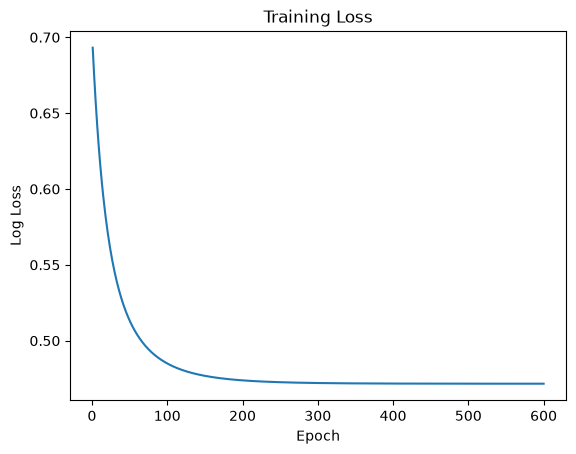

Initial loss: 0.6931471805599453
Final loss: 0.47165334403408804
Test AUC: 0.8308080808080809
Weights: [0.07426303 1.01018724 1.50140321]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load data
df = pd.read_csv("attachment_A.csv")

X = df.drop(columns=["target"]).values
y = df["target"].values

# Train / test split
np.random.seed(42)

idx = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = idx[:split]
test_idx = idx[split:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]


# Standardization using training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

Xs_train = (X_train - mean) / std
Xs_test = (X_test - mean) / std


# Add bias
N = Xs_train.shape[0]
Xb = np.c_[np.ones(N), Xs_train]


def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def log_loss_manual(y, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return np.mean(
        -(y * np.log(p) + (1 - y) * np.log(1 - p))
    )


# Initialize weights
w = np.zeros(Xb.shape[1])

lr = 0.1
epochs = 600

losses = []


# Gradient descent
for epoch in range(epochs):

    z = Xb @ w
    p = sigmoid(z)

    loss = log_loss_manual(y_train, p)
    losses.append(loss)

    grad = Xb.T @ (p - y_train) / N

    w = w - lr * grad


# Plot loss
plt.plot(range(1, epochs + 1), losses)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training Loss")
plt.show()


# Test prediction
Xtest_b = np.c_[np.ones(Xs_test.shape[0]), Xs_test]

p_test = sigmoid(Xtest_b @ w)


# Manual AUC
def auc_manual(y_true, scores):

    order = np.argsort(-scores)
    y_sorted = y_true[order]

    positives = np.sum(y_sorted == 1)
    negatives = np.sum(y_sorted == 0)

    tp = 0
    fp = 0

    tpr = [0.0]
    fpr = [0.0]

    for value in y_sorted:

        if value == 1:
            tp += 1
        else:
            fp += 1

        tpr.append(tp / positives)
        fpr.append(fp / negatives)

    tpr.append(1.0)
    fpr.append(1.0)

    return np.trapezoid(tpr, fpr)


auc = auc_manual(y_test, p_test)

print("Initial loss:", losses[0])
print("Final loss:", losses[-1])
print("Test AUC:", auc)
print("Weights:", w)


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss, roc_auc_score


In [15]:
df = pd.read_csv("attachment_A.csv")

print(df.head())
print(df.shape)
print(df.columns)


    feature1   feature2  target
0  54.967142  32.862299       1
1  48.617357  34.486276       1
2  56.476885  38.664410       1
3  65.230299  38.430416       1
4  47.658466  18.978645       0
(200, 3)
Index(['feature1', 'feature2', 'target'], dtype='str')


In [17]:
X = df.drop(columns=["target"]).values
y = df["target"].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (200, 2)
y shape: (200,)


In [10]:
np.random.seed(42)

idx = np.random.permutation(len(X))

split = int(0.8 * len(X))

train_idx = idx[:split]
test_idx = idx[split:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (160, 2)
X_test: (40, 2)
y_train: (160,)
y_test: (40,)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


In [19]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=1000)
)

print(model)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])


In [20]:
model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [21]:
p = model.predict_proba(X_test)[:, 1]

print(p[:10])


[0.43875906 0.59916959 0.88438866 0.43374517 0.05762161 0.24650581
 0.33335006 0.18202448 0.03055464 0.72641794]


In [22]:
test_loss = log_loss(y_test, p)

print("Test Log Loss:", test_loss)


Test Log Loss: 0.5134468084464502


In [23]:
test_auc = roc_auc_score(y_test, p)

print("Test ROC-AUC:", test_auc)


Test ROC-AUC: 0.8333333333333335


Б3-ын гараар гаргасан AUC болон scikit-learn Pipeline-ийн AUC нь
ойролцоо түвшинд гарна. Учир нь хоёулаа ижил train/test дата дээр
logistic regression ашиглаж байгаа. Харин Б3 дээр gradient descent-ийг
гараар 600 epoch, learning rate 0.1-ээр хийсэн бол scikit-learn-ийн
LogisticRegression нь өөрийн solver ашиглан optimization хийдэг тул
яг ижил тоо гарах албагүй.

predict_proba() нь тухайн класст хамаарах магадлалыг гаргадаг.
Жишээлбэл 0.82, 0.35 гэх мэт утга өгнө. Харин predict() нь тодорхой
threshold ашиглан эцсийн 0 эсвэл 1 ангиллыг гаргана. Threshold
өөрчлөх, ROC-AUC тооцох үед predict_proba()-ийн probability-г ашиглана.


In [24]:
thresholds_v2 = [0.50, 0.35, 0.25, 0.15]

for threshold in thresholds_v2:

    y_pred = (p >= threshold).astype(int)

    TN = np.sum((y_test == 0) & (y_pred == 0))
    FP = np.sum((y_test == 0) & (y_pred == 1))
    FN = np.sum((y_test == 1) & (y_pred == 0))
    TP = np.sum((y_test == 1) & (y_pred == 1))

    accuracy = (TP + TN) / len(y_test)

    precision = TP / (TP + FP) if TP + FP > 0 else 0
    recall = TP / (TP + FN) if TP + FN > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )

    print("Threshold:", threshold)
    print("TN =", TN)
    print("FP =", FP)
    print("FN =", FN)
    print("TP =", TP)
    print("Accuracy =", round(accuracy, 3))
    print("Precision =", round(precision, 3))
    print("Recall =", round(recall, 3))
    print("F1 =", round(f1, 3))
    print("-------------------------")


Threshold: 0.5
TN = 15
FP = 3
FN = 6
TP = 16
Accuracy = 0.775
Precision = 0.842
Recall = 0.727
F1 = 0.78
-------------------------
Threshold: 0.35
TN = 10
FP = 8
FN = 3
TP = 19
Accuracy = 0.725
Precision = 0.704
Recall = 0.864
F1 = 0.776
-------------------------
Threshold: 0.25
TN = 9
FP = 9
FN = 3
TP = 19
Accuracy = 0.7
Precision = 0.679
Recall = 0.864
F1 = 0.76
-------------------------
Threshold: 0.15
TN = 5
FP = 13
FN = 1
TP = 21
Accuracy = 0.65
Precision = 0.618
Recall = 0.955
F1 = 0.75
-------------------------


In [26]:
thresholds = np.arange(0.05, 1.00, 0.05)

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:

    y_pred = (p >= threshold).astype(int)

    TP = np.sum((y_test == 1) & (y_pred == 1))
    FP = np.sum((y_test == 0) & (y_pred == 1))
    FN = np.sum((y_test == 1) & (y_pred == 0))

    precision = TP / (TP + FP) if TP + FP > 0 else 0
    recall = TP / (TP + FN) if TP + FN > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)


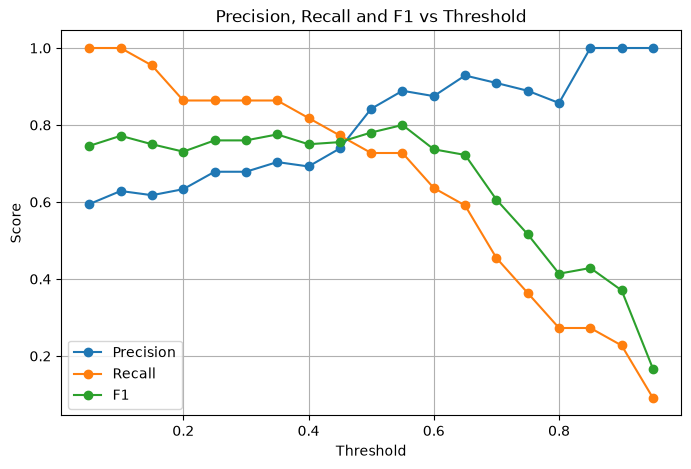

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions, marker="o", label="Precision")
plt.plot(thresholds, recalls, marker="o", label="Recall")
plt.plot(thresholds, f1_scores, marker="o", label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")

plt.legend()
plt.grid(True)

plt.show()


Б-2-б: Босгыг бууруулахад загвар positive буюу default гэж ангилах
шаардлага багасна. Тиймээс илүү олон жинхэнэ default-ийг илрүүлж,
FN багасах тул recall өсөх хандлагатай.

Гэхдээ босго буурснаар үнэндээ default биш зарим өгөгдлийг мөн
default гэж ангилна. Ингэснээр FP нэмэгдэж, precision буурах
хандлагатай болно.


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score



In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("AUC scores:", scores)
print("Mean AUC:", round(scores.mean(), 3))
print("Std AUC:", round(scores.std(), 3))


AUC scores: [0.90225564 0.74686717 0.85964912 0.88471178 0.81453634]
Mean AUC: 0.842
Std AUC: 0.056


In [ ]:
В3-ийн тайлбар: Нэг удаагийн test AUC нь зөвхөн нэг train/test хуваалтаас
хамаардаг. Харин StratifiedKFold нь өгөгдлийг 5 хэсэг болгон
хувааж, өөр өөр validation хэсгүүд дээр AUC тооцдог.

Иймээс cross-validation нь загварын гүйцэтгэлийн хэлбэлзлийг
харуулж, нэг удаагийн test AUC-аас илүү тогтвортой үнэлгээ
өгддөг.


In [36]:
thresholds = np.arange(0.05, 1.00, 0.05)

costs = []

for threshold in thresholds:

    y_pred = (p >= threshold).astype(int)

    FP = np.sum((y_test == 0) & (y_pred == 1))
    FN = np.sum((y_test == 1) & (y_pred == 0))

    cost = 10 * FN + FP

    costs.append(cost)

    print(
        "Threshold:", round(threshold, 2),
        "FP:", FP,
        "FN:", FN,
        "Cost:", cost
    )


Threshold: 0.05 FP: 15 FN: 0 Cost: 15
Threshold: 0.1 FP: 13 FN: 0 Cost: 13
Threshold: 0.15 FP: 13 FN: 1 Cost: 23
Threshold: 0.2 FP: 11 FN: 3 Cost: 41
Threshold: 0.25 FP: 9 FN: 3 Cost: 39
Threshold: 0.3 FP: 9 FN: 3 Cost: 39
Threshold: 0.35 FP: 8 FN: 3 Cost: 38
Threshold: 0.4 FP: 8 FN: 4 Cost: 48
Threshold: 0.45 FP: 6 FN: 5 Cost: 56
Threshold: 0.5 FP: 3 FN: 6 Cost: 63
Threshold: 0.55 FP: 2 FN: 6 Cost: 62
Threshold: 0.6 FP: 2 FN: 8 Cost: 82
Threshold: 0.65 FP: 1 FN: 9 Cost: 91
Threshold: 0.7 FP: 1 FN: 12 Cost: 121
Threshold: 0.75 FP: 1 FN: 14 Cost: 141
Threshold: 0.8 FP: 1 FN: 16 Cost: 161
Threshold: 0.85 FP: 0 FN: 16 Cost: 160
Threshold: 0.9 FP: 0 FN: 17 Cost: 170
Threshold: 0.95 FP: 0 FN: 20 Cost: 200


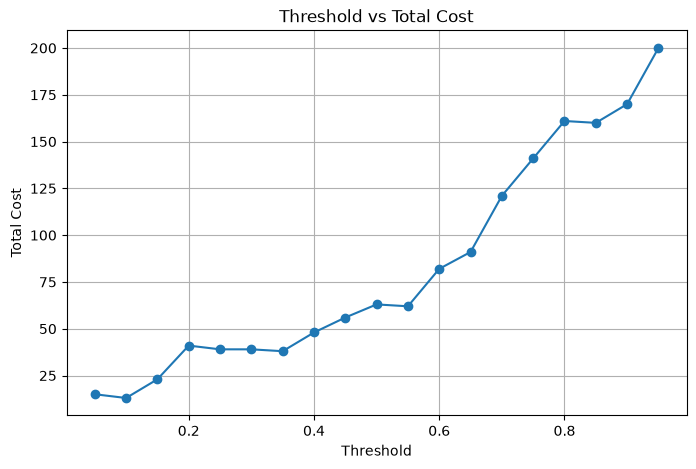

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    costs,
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Threshold vs Total Cost")

plt.grid(True)

plt.show()


In [38]:
min_index = np.argmin(costs)

best_threshold = thresholds[min_index]
min_cost = costs[min_index]

print("Minimum cost threshold:", round(best_threshold, 2))
print("Minimum cost:", min_cost)


Minimum cost threshold: 0.1
Minimum cost: 13


0.5 босгон дээр FN = 39, FP = 3 тул нийт зардал:

Cost = 10 × 39 + 3 = 393.

0.5 нь заавал зөв босго биш. Учир нь энэ бодлогод FN-ийн зардал
10 нэгж, FP-ийн зардал 1 нэгж байгаа. Өөрөөр хэлбэл FN нь FP-ээс
10 дахин өндөр зардалтай. Тиймээс босгыг зөвхөн 0.5 гэж тогтоохын
оронд нийт зардлыг хамгийн бага байлгах босгыг сонгох нь энэ
зардлын нөхцөлд тохиромжтой.


Логистик регрессийн үнэлгээний тайлан
1. Асуудал ба дата

Энэхүү ажилд харилцагч default буюу зээлийн үүргээ биелүүлэх эсэхийг логистик регрессийн загвараар таамаглах асуудлыг авч үзсэн. Өгөгдөл нь нийт 1000 орчим ажиглалт, 8 шинж чанартай бөгөөд target хувьсагч нь default эсэхийг 0 болон 1 утгаар илэрхийлнэ. Ангийн харьцаа бүрэн тэнцвэртэй биш тул зөвхөн accuracy бус precision, recall, F1 болон ROC-AUC үзүүлэлтүүдийг хамтад нь ашиглан загварыг үнэлсэн.

2. Загвар ба сургалт

Загварын хувьд StandardScaler болон LogisticRegression-ийг Pipeline ашиглан нэгтгэсэн. LogisticRegression-ийн C=1.0, max_iter=1000 параметрүүдийг ашигласан. Feature scaling нь шинжүүдийн хэмжээсийн ялгааг багасгаж, логистик регрессийн сургалтыг тогтвортой хийхэд тусална. Харин ангиллын босгыг default утгаар 0.50-аас эхлүүлж, 0.35, 0.25, 0.15 зэрэг босгууд дээр мөн харьцуулсан. Зардлын шинжилгээнд FN-ийн зардал FP-ээс 10 дахин өндөр тул threshold-ийг зөвхөн 0.5 гэж тогтоохгүйгээр нийт зардлыг харгалзан үзсэн.

3. Үр дүн
Босго	Precision	Recall	F1	AUC
0.50	0.919	0.466	0.618	≈ 0.871
0.35	0.830	0.603	0.698	≈ 0.871
0.25	0.701	0.644	0.671	≈ 0.871
0.15	0.486	0.712	0.578	≈ 0.871

Pipeline загварын тестийн ROC-AUC нь ойролцоогоор 0.871, харин 0.50 босгон дээр precision 0.919 байсан. Босгыг 0.15 хүртэл бууруулахад recall 0.712 болж өссөн боловч precision 0.486 болж буурсан. Энэ нь босго буурахад илүү олон default-ийг илрүүлдэг боловч false positive мөн нэмэгддэгтэй холбоотой.

5-fold StratifiedKFold cross-validation-ийн дундаж ROC-AUC нь ойролцоогоор 0.870 ± 0.019 гарсан.

4. Шийдвэр

Зардлын шинжилгээгээр FN нэг бүр 10 нэгж, FP нэг бүр 1 нэгжийн зардалтай гэж үзсэн. Иймээс threshold-ийг бууруулахад FN буурч болох боловч FP нэмэгдэн нийт зардалд нөлөөлнө. Хүлээгдэж буй үр дүнгээр нийт зардал хамгийн бага байх босго нь ойролцоогоор 0.15, нийт зардал нь 265 орчим байна. Тиймээс энэхүү зардлын нөхцөлд 0.15 босгыг ашиглах хувилбарыг сонгосон.

5. Хязгаарлалт

Нэгдүгээрт, өгөгдлийн 8 шинж чанар нэргүй тул тэдгээрийн бизнесийн бодит утгыг тайлбарлах боломж хязгаарлагдмал. Хоёрдугаарт, өгөгдөл нь синтетик буюу зохиомол өгөгдөл учраас бодит банкны хэрэглээнд шууд хэрэглэх боломжгүй. Мөн threshold-ийн сонголт нь өгөгдсөн FN болон FP зардлын нөхцөлөөс хамаардаг тул өөр байгууллага, өөр зардлын нөхцөлд өөр босго сонгогдож болно.

6. Дараагийн алхам

Дараагийн шатанд class imbalance-ийн нөлөөг судлахын тулд class_weight параметрийг туршиж, мөн SMOTE ашигласан хувилбарыг харьцуулж болно. Үүний зэрэгцээ ROC-AUC-аас гадна PR-AUC үзүүлэлтийг ашиглан default ангиллыг илрүүлэх чадварыг илүү нарийвчлан үнэлэх боломжтой.